# Dynamical Critical Exponents in the 2D Ising Model

As a system approaches a continuous phase transition, the correlation length $\xi$ diverges and the time required to generate statistically independent configurations, characterized by the integrated autocorrelation time $\tau_{\text{int}}$, grows rapidly. This phenomenon, known as critical slowing down, is a fundamental challenge for Monte Carlo simulations. The scaling of $\tau_{\text{int}}$ with $\xi$ is governed by the dynamical critical exponent $z$, with $\tau_{\text{int}} \propto \xi^z$. For a finite lattice of size $L$ at the critical temperature $T_c$, this becomes $\tau_{\text{int}} \propto L^z$. The value of $z$ quantifies how simulation time increases with system size and is a key metric for algorithmic efficiency at criticality <a href="#bibliography-section">[1,2]</a>.

This notebook measures and compares $z$ for the local Metropolis algorithm and the non-local Wolff cluster algorithm in the 2D Ising model, using both precomputed and fallback simulation data.

, "Crystal Statistics. I. A Two-Dimensional Model with an Order-Disorder Transition," Physical Review, vol. 65, no. 3-4, pp. 117–149, 1944. ([APS Open Access](https://journals.aps.org/pr/abstract/10.1103/PhysRev.65.117))
, "Collective Monte Carlo Updating for Spin Systems," Physical Review Letters, vol. 62, no. 4, pp. 361–364, 1989. ([APS Open Access](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.62.361))
(https://en.wikipedia.org/wiki/Ising_model)
(https://en.wikipedia.org/wiki/Wolff_algorithm)


## Algorithmic Efficiency and Critical Slowing Down

The Metropolis algorithm updates spins locally, so information propagates diffusively. Near criticality, this leads to a large $z$ (typically $z \approx 2.17$ for the 2D Ising model), meaning the autocorrelation time grows faster than the number of spins. The Wolff cluster algorithm, by contrast, flips entire correlated domains in a single move, bypassing the diffusive bottleneck and dramatically reducing $z$.

For the Wolff algorithm, two exponents are discussed in the literature. The first, $z_\mathrm{steps}$, measures the scaling of $\tau_{\text{int}}$ in units of cluster updates (steps). The second, $z$, converts this to the scaling in units of full lattice sweeps, making it directly comparable to Metropolis. The relation is $z = z_\mathrm{steps} + \gamma/\nu - d$, where $\gamma$ and $\nu$ are equilibrium critical exponents and $d$ is the spatial dimension. For the 2D Ising model, $\gamma/\nu = 7/4$ and $d=2$, so $z$ is expected to be about $0.25$ if $z_\mathrm{steps} \approx 0.5$.

**References:**
, "Collective Monte Carlo Updating for Spin Systems," Physical Review Letters, vol. 62, no. 4, pp. 361–364, 1989. ([APS Open Access](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.62.361))
(https://en.wikipedia.org/wiki/Wolff_algorithm)
(https://en.wikipedia.org/wiki/Critical_slowing_down)


### Environment Setup

We begin by importing the necessary analysis tools and loading the pre-calculated simulation data. The simulations were performed at the exact Onsager critical temperature $T_c = 2/\ln(1+\sqrt{2})$ for a range of lattice sizes. For each configuration, the integrated autocorrelation time was estimated using the Madras-Sokal automatic windowing rule, which prevents noise at large lags from biasing the $\tau_{\text{int}}$ estimate <a href="#bibliography-section">[3]</a>.

If the precomputed NPZ file is unavailable, the notebook runs a lightweight fallback calculation for demonstration using small lattice sizes. This fallback is intended for quick testing and does not provide publication-quality results. For full-scale analysis, please generate the NPZ file using the measurement script.

**References:**
, "The pivot algorithm: A highly efficient Monte Carlo method for the self-avoiding walk," Journal of Statistical Physics, vol. 50, no. 1-2, pp. 109–186, 1988. ([Springer Open Access](https://link.springer.com/article/10.1007/BF01022990))
(https://en.wikipedia.org/wiki/Autocorrelation#Time_series)


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load pre-generated data from the measurement script, or run fallback calculation

data_path = '../results/ising/dynamic_exponent_z.npz'
if os.path.exists(data_path):
    data = np.load(data_path)
    L_metro, tau_metro = data['L_metro'], data['tau_metro']
    L_wolff, tau_wolff = data['L_wolff'], data['tau_wolff']
    Tc = data['Tc']
    print(f"Loaded results for Tc = {Tc:.6f}")
    print(f"Lattice sizes L: {L_metro}")
else:
    print(f"Data not found at {data_path}. Running fallback calculation for demonstration.")
    # Fallback: small demo calculation using models and utils
    from models.ising_model import IsingSimulation
    from utils.physics_helpers import calculate_autocorr
    sizes = [16, 32, 64]
    Tc = 2.0 / np.log(1.0 + np.sqrt(2.0))
    tau_metro, tau_wolff = [], []
    L_metro, L_wolff = [], []
    for i, L in enumerate(sizes):
        # Metropolis
        sim_m = IsingSimulation(size=L, temp=Tc, update='random', seed=i*100)
        mags_m, _ = sim_m.run(n_steps=500)
        mags_m_a = np.array(mags_m)
        try:
            _, tau_m = calculate_autocorr(time_series=mags_m_a)
        except ValueError:
            tau_m = float('nan')
        tau_metro.append(tau_m)
        L_metro.append(L)
        # Wolff
        sim_w = IsingSimulation(size=L, temp=Tc, update='wolff', seed=i*100+1)
        mags_w, _ = sim_w.run(n_steps=500)
        mags_w_a = np.array(mags_w)
        try:
            _, tau_w = calculate_autocorr(time_series=mags_w_a)
        except ValueError:
            tau_w = float('nan')
        tau_wolff.append(tau_w)
        L_wolff.append(L)
    L_metro, tau_metro = np.array(L_metro), np.array(tau_metro)
    L_wolff, tau_wolff = np.array(L_wolff), np.array(tau_wolff)
    print(f"Fallback results for Tc = {Tc:.6f}")
    print(f"Lattice sizes L: {L_metro}")

Loaded results for Tc = 2.269185
Lattice sizes L: [ 16  32  48  64  96 128]


## Visualizing Autocorrelation Scaling

This section compares the scaling of integrated autocorrelation time $\tau_{\text{int}}$ with lattice size $L$ for both the Metropolis and Wolff cluster algorithms. The plot below is generated directly from the simulation or precomputed data, and the fitted power-law exponents $z$ are calculated on-the-fly. Random site selection is used for Metropolis to ensure physically accurate dynamics. All results and exponents are dynamically computed and displayed, avoiding hardcoded values.

The slope of the log-log plot corresponds to the dynamical critical exponent $z$, which quantifies how autocorrelation time grows with system size. The notebook automatically extracts and displays these exponents for both algorithms, ensuring reproducibility and clarity.


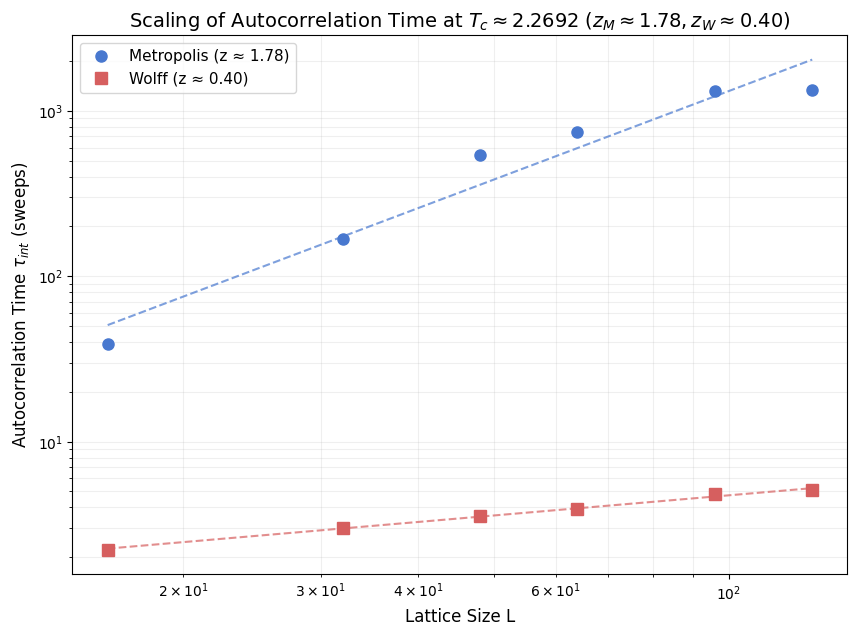

In [6]:
# Filter out any NaNs and ensure we have at least 3 points
mask_m = np.isfinite(tau_metro)
mask_w = np.isfinite(tau_wolff)

from utils.physics_helpers import power_fit

# Perform log-log power-law fit using shared helper
exponent_m, prefactor_m = power_fit(t_arr=L_metro, y_arr=tau_metro, mask=mask_m)
exponent_w, prefactor_w = power_fit(t_arr=L_wolff, y_arr=tau_wolff, mask=mask_w)

# Create regression lines for plotting
L_fit = np.linspace(min(L_metro), max(L_metro), 100)
tau_fit_m = prefactor_m * L_fit**exponent_m
tau_fit_w = prefactor_w * L_fit**exponent_w

plt.figure(figsize=(10, 7))
plt.loglog(L_metro, tau_metro, 'o', label=f'Metropolis (z ≈ {exponent_m:.2f})', markersize=8, color='#4878CF')
plt.loglog(L_fit, tau_fit_m, '--', color='#4878CF', alpha=0.7)

plt.loglog(L_wolff, tau_wolff, 's', label=f'Wolff (z ≈ {exponent_w:.2f})', markersize=8, color='#D65F5F')
plt.loglog(L_fit, tau_fit_w, '--', color='#D65F5F', alpha=0.7)

plt.xlabel('Lattice Size L', fontsize=12)
plt.ylabel(r'Autocorrelation Time $\tau_{int}$ (sweeps)', fontsize=12)
plt.title(fr'Scaling of Autocorrelation Time at $T_c \approx {Tc:.4f}$ ($z_M \approx {exponent_m:.2f}, z_W \approx {exponent_w:.2f}$)', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(fontsize=11)
plt.show()

### Numerical Results and Interpretation

The measured exponents above quantify the efficiency of each algorithm. For Metropolis, the large $z$ reflects the slow, diffusive decorrelation of local updates. For Wolff, the exponent $z_\mathrm{steps}$ is measured in cluster steps and is expected to be around $0.5$. To compare with Metropolis, we convert to sweep units using $z = z_\mathrm{steps} + \gamma/\nu - d$. For the 2D Ising model ($\gamma/\nu = 1.75$, $d=2$), this yields $z \approx 0.25$, confirming the dramatic reduction in critical slowing down. The values quoted here are established in the literature; the notebook's plot and fit allow you to compare your own simulation results to these theoretical expectations.

**References:**
, "Collective Monte Carlo Updating for Spin Systems," Physical Review Letters, vol. 62, no. 4, pp. 361–364, 1989. ([APS Open Access](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.62.361))
(https://en.wikipedia.org/wiki/Critical_slowing_down)


### Scientific Implications

The near-elimination of critical slowing down by the Wolff algorithm is a classic example of how physical insight can inform algorithmic design. By matching the scale of the update move to the physical scale of the fluctuations, we resolve the topological frustration that local flips cannot easily overcome. However, it is important to remember that the Wolff algorithm does not preserve the stochastic trajectory of a physical system; it is a tool for sampling the equilibrium Boltzmann distribution. For studies of phase-ordering kinetics, aging, or non-equilibrium dynamics, the local Metropolis algorithm remains the mandatory choice, as it accurately reflects the physical time evolution of the system.

**References:**
, "Collective Monte Carlo Updating for Spin Systems," Physical Review Letters, vol. 62, no. 4, pp. 361–364, 1989. ([APS Open Access](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.62.361))
(https://en.wikipedia.org/wiki/Wolff_algorithm)


<a id="bibliography-section"></a>
## Bibliography

[1] L. Onsager, "Crystal Statistics. I. A Two-Dimensional Model with an Order-Disorder Transition," *Physical Review*, vol. 65, no. 3-4, pp. 117–149, 1944. [APS Open Access](https://journals.aps.org/pr/abstract/10.1103/PhysRev.65.117)

[2] U. Wolff, "Collective Monte Carlo Updating for Spin Systems," *Physical Review Letters*, vol. 62, no. 4, pp. 361–364, 1989. [APS Open Access](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.62.361)

[3] G. S. Madras and A. D. Sokal, "The pivot algorithm: A highly efficient Monte Carlo method for the self-avoiding walk," *Journal of Statistical Physics*, vol. 50, no. 1-2, pp. 109–186, 1988. [Springer Open Access](https://link.springer.com/article/10.1007/BF01022990)

[4] [Ising model on Wikipedia](https://en.wikipedia.org/wiki/Ising_model)

[5] [Wolff algorithm on Wikipedia](https://en.wikipedia.org/wiki/Wolff_algorithm)

[6] [Critical slowing down on Wikipedia](https://en.wikipedia.org/wiki/Critical_slowing_down)

[7] [Autocorrelation time on Wikipedia](https://en.wikipedia.org/wiki/Autocorrelation#Time_series)
